# SVM Basics
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Support vectors, margin, and the difference between linear and RBF kernels.

Main goals:

- Visualise the maximum-margin hyperplane and support vectors on linearly separable data.
- Fit a linear kernel SVM and inspect the support vectors directly.
- Fit an RBF kernel SVM on data that is not linearly separable.
- Compare linear vs RBF decision boundaries.

---

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Margin and Support Vectors

In [2]:
X, y = make_blobs(n_samples=60, centers=2, cluster_std=0.9, random_state=6)

model = SVC(kernel='linear', C=1000)
model.fit(X, y)

print('Number of support vectors per class:', model.n_support_)
print('Total support vectors:', len(model.support_vectors_))

Number of support vectors per class: [2 1]
Total support vectors: 3


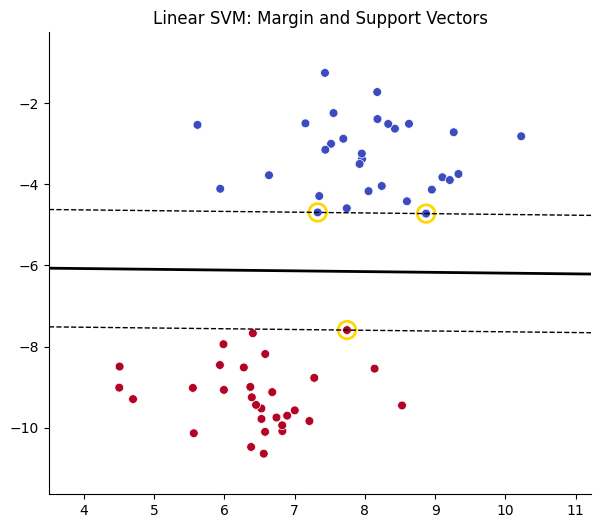

In [3]:
def plot_svm_boundary(model, X, y, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=40, edgecolors='white', lw=0.5)

    xlim = ax.get_xlim() if ax.get_xlim() != (0, 1) else (X[:,0].min()-1, X[:,0].max()+1)
    ax.set_xlim(X[:,0].min()-1, X[:,0].max()+1)
    ax.set_ylim(X[:,1].min()-1, X[:,1].max()+1)

    xx, yy = np.meshgrid(np.linspace(*ax.get_xlim(), 200), np.linspace(*ax.get_ylim(), 200))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contour(xx, yy, Z, colors='black', levels=[-1, 0, 1],
               linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

    if hasattr(model, 'support_vectors_'):
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=160, facecolors='none', edgecolors='gold', linewidths=2)
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(7, 6))
plot_svm_boundary(model, X, y, ax, 'Linear SVM: Margin and Support Vectors')
plt.show()

**Observation:**
Gold-circled points are the support vectors — only the points closest to the boundary. Moving any non-support-vector point slightly would not change the decision boundary at all.

## Effect of C

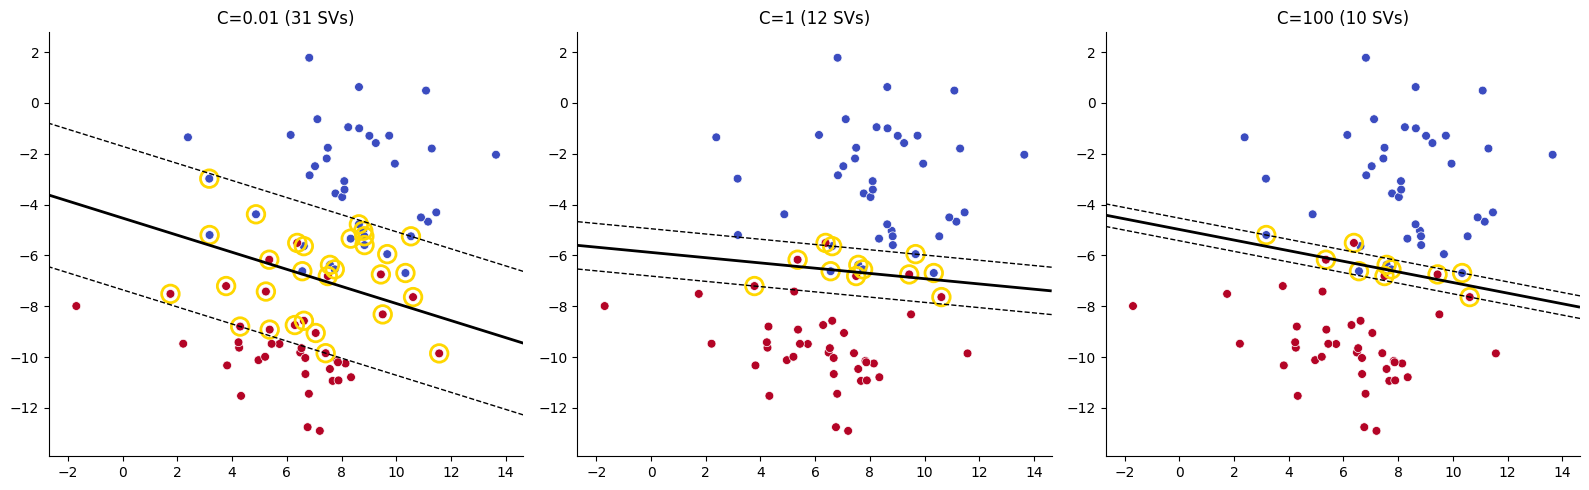

In [4]:
X_overlap, y_overlap = make_blobs(n_samples=80, centers=2, cluster_std=2.2, random_state=6)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, C in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel='linear', C=C).fit(X_overlap, y_overlap)
    plot_svm_boundary(m, X_overlap, y_overlap, ax, f'C={C} ({len(m.support_vectors_)} SVs)')
plt.tight_layout()
plt.show()

**Observation:**
Small C allows a wider margin with more misclassified points inside it. Large C forces a narrower margin that fits the training data more tightly, with fewer support vectors. Same bias-variance tradeoff seen with regularisation in Logistic Regression.

## Linear Kernel on Non-Linearly-Separable Data

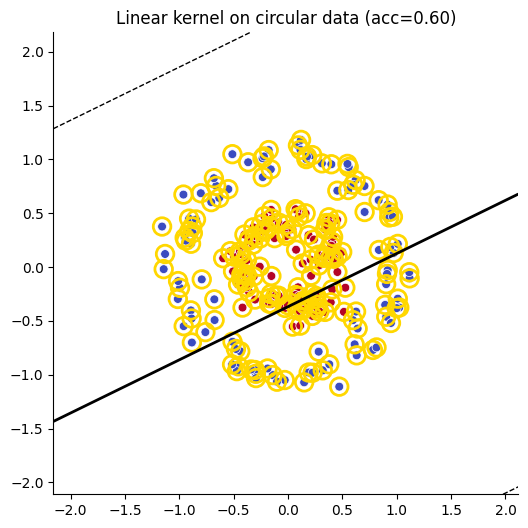

In [5]:
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

linear_model = SVC(kernel='linear', C=1)
linear_model.fit(X_circles, y_circles)

fig, ax = plt.subplots(figsize=(6, 6))
plot_svm_boundary(linear_model, X_circles, y_circles, ax,
                  f'Linear kernel on circular data (acc={accuracy_score(y_circles, linear_model.predict(X_circles)):.2f})')
plt.show()

**Observation:**
A straight line cannot separate an inner circle from an outer ring — linear kernel performs close to chance here.

## RBF Kernel

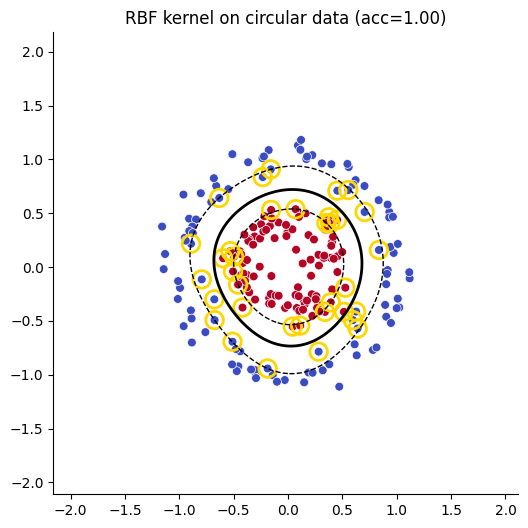

In [6]:
rbf_model = SVC(kernel='rbf', C=1, gamma='scale')
rbf_model.fit(X_circles, y_circles)

fig, ax = plt.subplots(figsize=(6, 6))
plot_svm_boundary(rbf_model, X_circles, y_circles, ax,
                  f'RBF kernel on circular data (acc={accuracy_score(y_circles, rbf_model.predict(X_circles)):.2f})')
plt.show()

**Observation:**
RBF kernel maps the data into a higher-dimensional space where the circular pattern becomes separable, and the boundary curves around the inner cluster rather than being a straight line.

## Linear vs RBF Side by Side

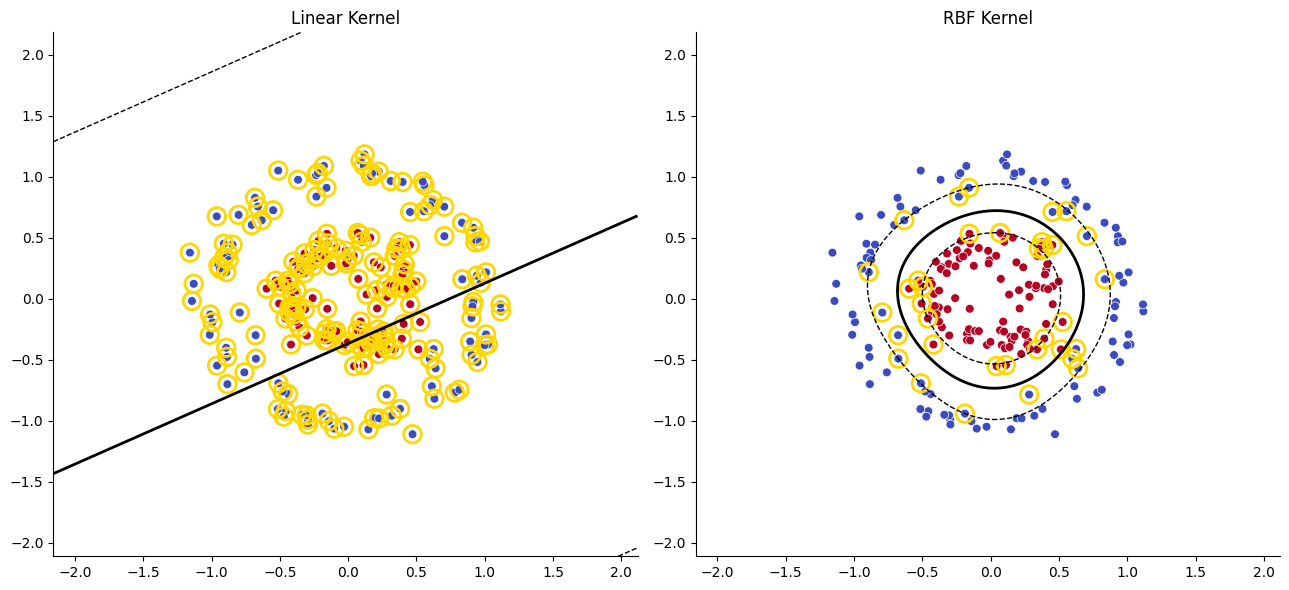

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_svm_boundary(linear_model, X_circles, y_circles, axes[0], 'Linear Kernel')
plot_svm_boundary(rbf_model, X_circles, y_circles, axes[1], 'RBF Kernel')
plt.tight_layout()
plt.show()

## RBF gamma Effect

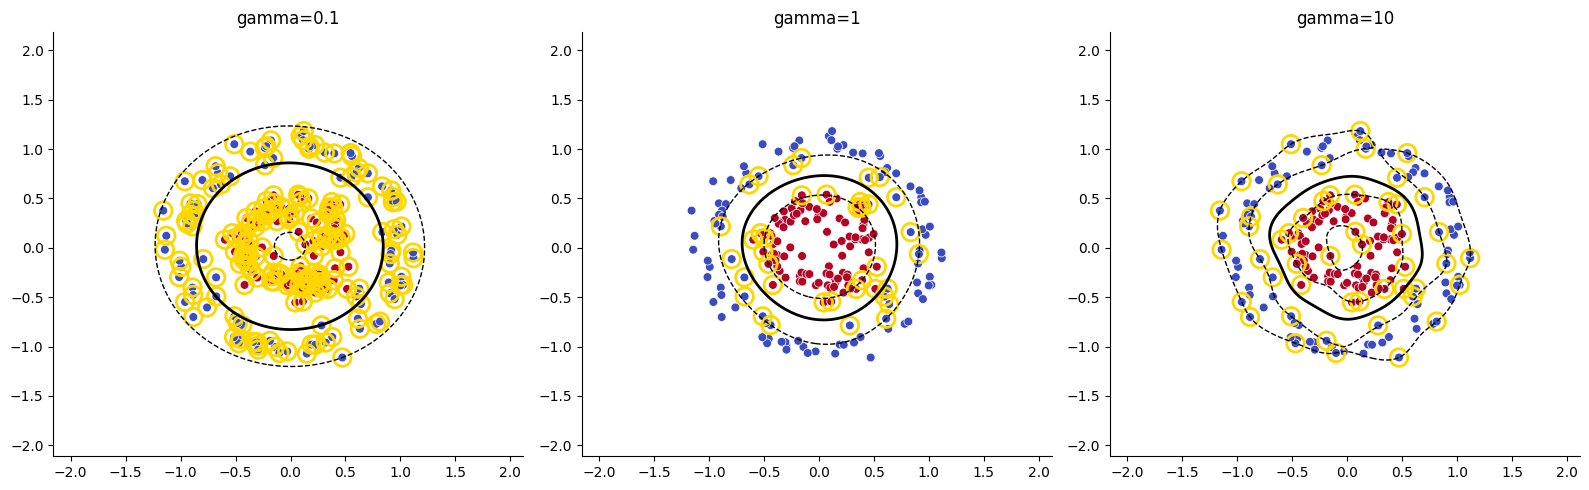

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, gamma in zip(axes, [0.1, 1, 10]):
    m = SVC(kernel='rbf', C=1, gamma=gamma).fit(X_circles, y_circles)
    plot_svm_boundary(m, X_circles, y_circles, ax, f'gamma={gamma}')
plt.tight_layout()
plt.show()

**Observation:**
Low gamma gives a smoother, more generalised boundary. High gamma fits tightly around individual points — same overfitting risk as a high C, just controlled by a different parameter.